In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the training dataset
df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")

# Display the first rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
# Remove the completely empty row
df = df.dropna()

# Remove CustomerID because it is only an identifier
df = df.drop(columns=["CustomerID"])

# Check the final dataset shape
print("Dataset shape:", df.shape)

Dataset shape: (440832, 11)


In [4]:
# Separate input features from the target variable
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (440832, 10)
y shape: (440832,)


In [5]:
# Split the data into 80% training and 20% validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (352665, 10)
Validation set: (88167, 10)


In [6]:
# Define numerical and categorical features
numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

In [7]:
# Import preprocessing tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scale numerical features and encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
# Import Logistic Regression and Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Gender','Tenure',...,'Contract Length','Total Spend', 'Last Interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [9]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions
logistic_pred = logistic_model.predict(X_val)
logistic_prob = logistic_model.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_val, logistic_pred)
logistic_precision = precision_score(y_val, logistic_pred)
logistic_recall = recall_score(y_val, logistic_pred)
logistic_f1 = f1_score(y_val, logistic_pred)
logistic_auc = roc_auc_score(y_val, logistic_prob)

# Display results
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_auc:.4f}")

Accuracy:  0.8934
Precision: 0.9234
Recall:    0.8855
F1-score:  0.9040
ROC-AUC:   0.9590


In [10]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline for the Random Forest model
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Gender','Tenure',...,'Contract Length','Total Spend', 'Last Interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [11]:
# Make predictions using the Random Forest model
rf_pred = random_forest_model.predict(X_val)

# Get churn probabilities
rf_prob = random_forest_model.predict_proba(X_val)[:, 1]

In [12]:
# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)
rf_f1 = f1_score(y_val, rf_pred)
rf_auc = roc_auc_score(y_val, rf_prob)

# Display the results
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

Accuracy:  0.9993
Precision: 0.9999
Recall:    0.9988
F1-score:  0.9993
ROC-AUC:   1.0000


In [13]:
# Compare Random Forest performance on training and validation data
train_accuracy = random_forest_model.score(X_train, y_train)
val_accuracy = random_forest_model.score(X_val, y_val)

print(f"Training Accuracy:   {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Difference:          {(train_accuracy - val_accuracy) * 100:.2f}%")

Training Accuracy:   100.00%
Validation Accuracy: 99.93%
Difference:          0.07%


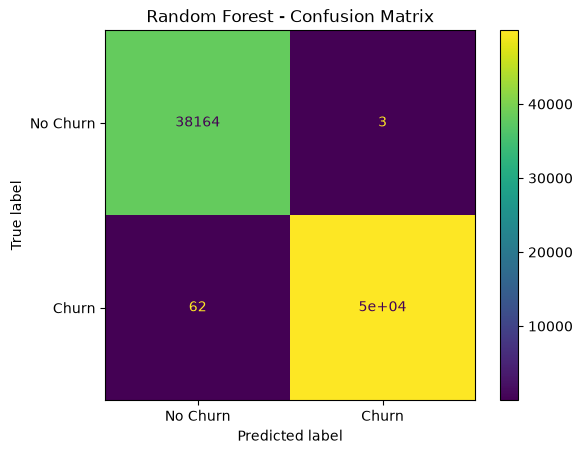

In [14]:
# Display the Random Forest confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_val, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [15]:
# Create training and validation data without Contract Length
X_train_no_contract = X_train.drop(columns=["Contract Length"])
X_val_no_contract = X_val.drop(columns=["Contract Length"])

# Define categorical features without Contract Length
categorical_features_no_contract = [
    "Gender",
    "Subscription Type"
]

# Create preprocessing pipeline without Contract Length
preprocessor_no_contract = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_no_contract)
    ]
)

In [16]:
# Create Random Forest without Contract Length
rf_no_contract = Pipeline(
    steps=[
        ("preprocessor", preprocessor_no_contract),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
rf_no_contract.fit(X_train_no_contract, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','Gender','Tenure',...,'Subscription Type','Total Spend', 'Last Interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [17]:
# Evaluate Random Forest without Contract Length
rf_no_contract_pred = rf_no_contract.predict(X_val_no_contract)
rf_no_contract_prob = rf_no_contract.predict_proba(X_val_no_contract)[:, 1]

accuracy_no_contract = accuracy_score(y_val, rf_no_contract_pred)
auc_no_contract = roc_auc_score(y_val, rf_no_contract_prob)

print(f"Accuracy without Contract Length: {accuracy_no_contract * 100:.2f}%")
print(f"ROC-AUC without Contract Length:  {auc_no_contract:.4f}")

Accuracy without Contract Length: 98.80%
ROC-AUC without Contract Length:  0.9896


In [18]:
# Get feature names after preprocessing
feature_names = random_forest_model[
    "preprocessor"
].get_feature_names_out()

# Get feature importance scores from Random Forest
feature_importance = random_forest_model[
    "classifier"
].feature_importances_

# Create a DataFrame with feature importance values
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort features from most to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
3,num__Support Calls,0.293023
5,num__Total Spend,0.199928
0,num__Age,0.130458
4,num__Payment Delay,0.128449
13,cat__Contract Length_Monthly,0.100309
6,num__Last Interaction,0.048592
12,cat__Contract Length_Annual,0.024560
14,cat__Contract Length_Quarterly,0.020682
8,cat__Gender_Male,0.018286
7,cat__Gender_Female,0.017295


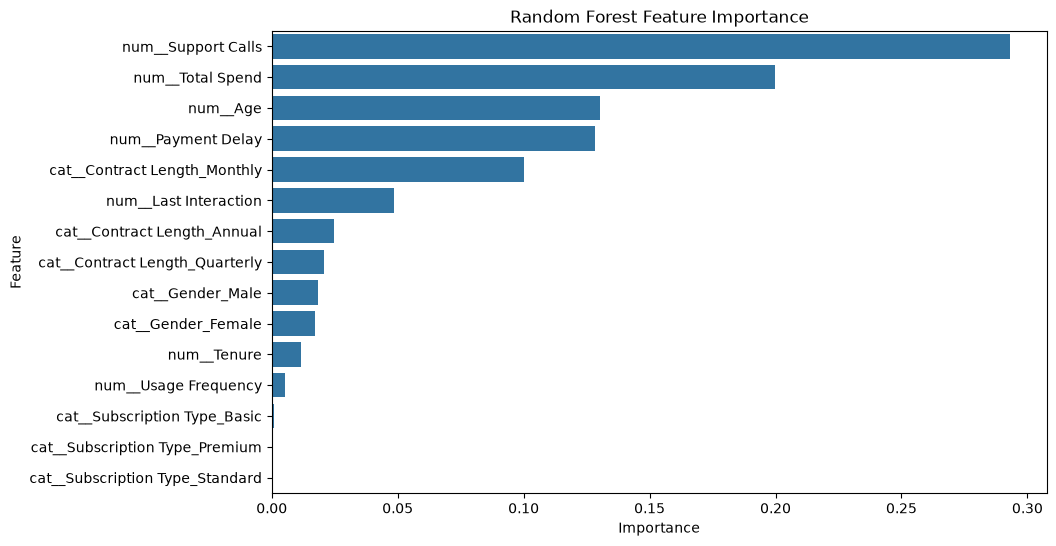

In [19]:
# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [20]:
# Import cross-validation tools
from sklearn.model_selection import StratifiedKFold, cross_validate

# Create 5 stratified folds
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate Random Forest across all folds
cv_results = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

In [21]:
# Display the accuracy score for each fold
for i, score in enumerate(cv_results["test_accuracy"], start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

# Display the mean and variation across folds
print(f"\nMean Accuracy: {cv_results['test_accuracy'].mean() * 100:.2f}%")
print(f"Std Accuracy:  {cv_results['test_accuracy'].std() * 100:.4f}%")

print(f"\nMean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1-score:  {cv_results['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f}")

Fold 1: 99.92%
Fold 2: 99.92%
Fold 3: 99.91%
Fold 4: 99.93%
Fold 5: 99.94%

Mean Accuracy: 99.92%
Std Accuracy:  0.0072%

Mean Precision: 1.0000
Mean Recall:    0.9987
Mean F1-score:  0.9993
Mean ROC-AUC:   1.0000


In [22]:
# Load the independent test dataset
test_df = pd.read_csv("../data/customer_churn_dataset-testing-master.csv")

# Check the test dataset structure
print("Test shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(test_df.isnull().sum())

Test shape: (64374, 12)

Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [23]:
# Preview the test dataset
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [24]:
# Prepare the independent test dataset
test_df = test_df.drop(columns=["CustomerID"])

# Separate test features and target
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

# Check the final shapes
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (64374, 10)
y_test shape: (64374,)


In [25]:
# Make predictions on the independent test set
test_pred = random_forest_model.predict(X_test)

# Get churn probabilities
test_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate final test metrics
test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

# Display final test results
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")

Test Accuracy:  0.5041
Test Precision: 0.4885
Test Recall:    0.9987
Test F1-score:  0.6561
Test ROC-AUC:   0.6123


In [26]:
# Compare churn distribution between training and test datasets
print("Training Churn Distribution:")
print(y.value_counts(normalize=True).sort_index() * 100)

print("\nTest Churn Distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

# Check how often the model predicts each class on the test set
print("\nModel Predictions on Test Set:")
print(
    pd.Series(test_pred)
    .value_counts(normalize=True)
    .sort_index() * 100
)

Training Churn Distribution:
Churn
0.0    43.28928
1.0    56.71072
Name: proportion, dtype: float64

Test Churn Distribution:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64

Model Predictions on Test Set:
0.0     3.162768
1.0    96.837232
Name: proportion, dtype: float64


In [27]:
# Compare key numerical features between training and test datasets
features_to_compare = [
    "Age",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    "Tenure",
    "Usage Frequency"
]

comparison = pd.DataFrame({
    "Train Mean": X_train[features_to_compare].mean(),
    "Test Mean": X_test[features_to_compare].mean(),
    "Train Min": X_train[features_to_compare].min(),
    "Test Min": X_test[features_to_compare].min(),
    "Train Max": X_train[features_to_compare].max(),
    "Test Max": X_test[features_to_compare].max()
})

comparison.round(2)

,Train Mean,Test Mean,Train Min,Test Min,Train Max,Test Max
Age,39.38,41.97,18.0,18,65.0,65
Support Calls,3.61,5.40,0.0,0,10.0,10
Payment Delay,12.97,17.13,0.0,0,30.0,30
Total Spend,631.89,541.02,100.0,100,1000.0,1000
Last Interaction,14.48,15.50,1.0,1,30.0,30
Tenure,31.24,31.99,1.0,1,60.0,60
Usage Frequency,15.82,15.08,1.0,1,30.0,30


In [28]:
# Compare Contract Length distribution between training and test datasets
print("Training Contract Length:")
print(X_train["Contract Length"].value_counts(normalize=True) * 100)

print("\nTest Contract Length:")
print(X_test["Contract Length"].value_counts(normalize=True) * 100)

Training Contract Length:
Contract Length
Annual       40.134122
Quarterly    40.062949
Monthly      19.802929
Name: proportion, dtype: float64

Test Contract Length:
Contract Length
Monthly      34.377233
Annual       33.258769
Quarterly    32.363998
Name: proportion, dtype: float64


In [29]:
# Compare feature means by Churn class in training data
train_by_churn = df.groupby("Churn")[
    [
        "Support Calls",
        "Payment Delay",
        "Total Spend",
        "Age",
        "Last Interaction"
    ]
].mean()

print("Training Data:")
display(train_by_churn)

# Compare feature means by Churn class in test data
test_by_churn = test_df.groupby("Churn")[
    [
        "Support Calls",
        "Payment Delay",
        "Total Spend",
        "Age",
        "Last Interaction"
    ]
].mean()

print("\nTest Data:")
display(test_by_churn)

Training Data:


,Support Calls,Payment Delay,Total Spend,Age,Last Interaction
Churn,,,,,
0.0,1.586418,10.015500,749.953111,36.262973,13.008804
1.0,5.144861,15.217729,541.285528,41.747263,15.604546



Test Data:


,Support Calls,Payment Delay,Total Spend,Age,Last Interaction
Churn,,,,,
0,4.500753,12.453086,560.541956,41.132700,15.521944
1,6.400617,22.334897,519.336143,42.902404,15.473191


In [30]:
# Evaluate Logistic Regression on the independent test set
lr_test_pred = logistic_model.predict(X_test)
lr_test_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate test metrics
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)
lr_test_precision = precision_score(y_test, lr_test_pred)
lr_test_recall = recall_score(y_test, lr_test_pred)
lr_test_f1 = f1_score(y_test, lr_test_pred)
lr_test_auc = roc_auc_score(y_test, lr_test_prob)

# Display Logistic Regression test results
print(f"Test Accuracy:  {lr_test_accuracy:.4f}")
print(f"Test Precision: {lr_test_precision:.4f}")
print(f"Test Recall:    {lr_test_recall:.4f}")
print(f"Test F1-score:  {lr_test_f1:.4f}")
print(f"Test ROC-AUC:   {lr_test_auc:.4f}")

Test Accuracy:  0.5712
Test Precision: 0.5251
Test Recall:    0.9906
Test F1-score:  0.6864
Test ROC-AUC:   0.6894


In [31]:
# Check Logistic Regression prediction distribution on the test set
print("Logistic Regression Predictions:")
print(
    pd.Series(lr_test_pred)
    .value_counts(normalize=True)
    .sort_index() * 100
)

Logistic Regression Predictions:
0.0    10.642495
1.0    89.357505
Name: proportion, dtype: float64


In [32]:
# Create a final comparison of model performance on the independent test set
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_test_accuracy,
        test_accuracy
    ],
    "Precision": [
        lr_test_precision,
        test_precision
    ],
    "Recall": [
        lr_test_recall,
        test_recall
    ],
    "F1 Score": [
        lr_test_f1,
        test_f1
    ],
    "ROC-AUC": [
        lr_test_auc,
        test_auc
    ]
})

# Display the final comparison
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5712,0.5251,0.9906,0.6864,0.6894
1,Random Forest,0.5041,0.4885,0.9987,0.6561,0.6123


## Final Evaluation & Dataset Shift Findings

Both models performed substantially worse on the provided independent test dataset compared with their validation performance.

### Model Performance

- Logistic Regression achieved approximately 89% validation accuracy but dropped to approximately 57% on the independent test set.
- Random Forest achieved approximately 99.9% validation accuracy and approximately 99.9% mean accuracy during 5-fold cross-validation, but dropped to approximately 50% on the independent test set.

### Investigation

Further analysis revealed substantial differences between the training and test datasets.

Several important features showed distribution changes, including:

- Support Calls
- Payment Delay
- Total Spend
- Contract Length

For example, the average number of Support Calls increased from approximately 3.6 in the training data to 5.4 in the test data.

The relationship between some features and the target variable also changed between the datasets. Customers without churn in the test set had feature values that were more similar to churned customers in the training set.

As a result, both models predicted Churn for a very large proportion of the independent test customers.

### Conclusion

The experiments indicate a significant dataset distribution shift between the provided training and test datasets.

Although the models show strong performance when evaluated within the training-data distribution, their performance does not generalize reliably to the provided independent test dataset.

Therefore, the current models should not be considered production-ready based on these datasets alone. Additional representative data and further investigation into the data-generation and train/test splitting process would be required before deployment.